# 48 — Spatiotemporal attention and non-local blocks

A [3D convolution](./46_3d_convolution_and_spatiotemporal_receptive_fields.ipynb) exchanges information inside a local space-time window. Reaching a distant frame or image location therefore requires several layers. A non-local block instead lets every space-time position attend directly to every other position.

This notebook connects video feature maps to the [attention machinery](./32_multi_head_attention.ipynb) developed earlier: flatten space and time into tokens, calculate global self-attention, restore the video layout, and wrap the operation in a residual block.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.manual_seed(17)

## 1. Turn a video feature map into tokens

A 3D CNN commonly stores features as `(N, C, T, H, W)`. Attention expects a sequence `(N, L, C)`, where each token contains the `C` features at one space-time position and

$$L=T H W.$$

We first move the channel axis to the end and then merge `(T,H,W)`. Reshape alone is insufficient because channels are not adjacent to each individual position in the original layout.

Keeping the flattened features as `(N,C,THW)` is also valid and is convenient for keys. Attention conventionally represents queries as `(N,THW,C)`, however, so that each row is one position with `C` features. This gives `(N,THW,C) @ (N,C,THW) → (N,THW,THW)`, comparing every query position with every key position. We could first reshape to `(N,C,THW)` and then transpose axes 1 and 2; this is equivalent to moving channels last before reshaping. Directly reshaping `(N,C,T,H,W)` into `(N,THW,C)` without either reordering step would group values from different positions rather than the `C` channels of one position.

The synthetic feature map below contains the same distinctive feature vector at two distant positions: the first location in frame 0 and the last location in frame 2.

### Exercise 1 — Flatten space-time positions

In [2]:
features = 0.05 * torch.randn(1, 4, 3, 2, 2)
signature = torch.tensor([1.5, -1.0, 0.5, 2.0])
features[0, :, 0, 0, 0] = signature
features[0, :, 2, 1, 1] = signature

def video_features_to_tokens(features):
    """Convert (N, C, T, H, W) features to (N, T*H*W, C)."""
    if features.ndim != 5:
        raise ValueError("features must have shape (N, C, T, H, W)")
    n, channels, time, height, width = features.shape
    # move channels last, then merge time, height, and width.
    tokens = torch.permute(features, (0, 2, 3, 4, 1))
    tokens = tokens.reshape((n, time*height*width, channels))
    return tokens

tokens = video_features_to_tokens(features)
assert tokens.shape == (1, 12, 4)
torch.testing.assert_close(tokens[0, 0], signature)
torch.testing.assert_close(tokens[0, 11], signature)

## 2. Global attention across space and time

For a minimal demonstration, the tokens themselves act as queries, keys, and values. In a learned block, separate projections produce these arrays. Scaled dot-product attention is

$$S=\frac{QK^T}{\sqrt{d}}, \qquad A=\mathrm{softmax}(S), \qquad Y=AV.$$

Each row of `A` belongs to one query position and contains its weights over all `L` key positions. Thus `A` has shape `(N,L,L)`. This is called **non-local** because a query is not restricted to a nearby convolutional window.

### Exercise 2 — Calculate spatiotemporal self-attention

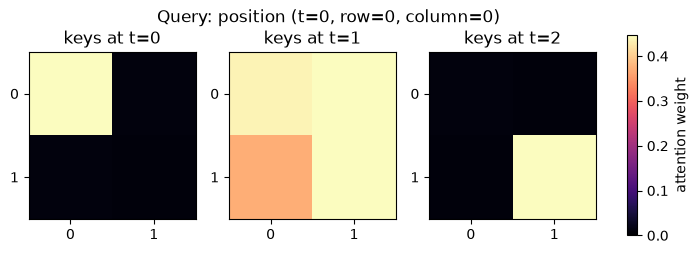

In [3]:
def scaled_dot_product_attention(query, key, value):
    """Return attended values and row-wise attention weights."""
    feature_dimension = query.shape[-1]
    # Swap only the last two axes: (N, L, C) → (N, C, L), while the
    # leading batch axis stays in place. This makes (L, C) @ (C, L) valid.
    scores = query @ key.transpose(-2, -1)
    scores = scores / np.sqrt(feature_dimension)
    # The last scores axis enumerates keys, so dim=-1 makes every query's
    # weights over all keys sum to one without mixing queries or batches.
    attention_weights = torch.softmax(scores, dim=-1)
    # use the weights to combine value vectors.
    attended = attention_weights @ value
    return attended, attention_weights

attended_tokens, attention_weights = scaled_dot_product_attention(
    tokens, tokens, tokens
)
assert attended_tokens.shape == tokens.shape
assert attention_weights.shape == (1, 12, 12)
torch.testing.assert_close(
    attention_weights.sum(dim=-1), torch.ones(1, 12)
)

query_weights = attention_weights[0, 0].reshape(3, 2, 2).detach() # 3, 2, 2 -> T, H, W
fig, axes = plt.subplots(1, 3, figsize=(8, 2.6))
for t, axis in enumerate(axes):
    image_handle = axis.imshow(query_weights[t], cmap="magma", vmin=0)
    axis.set_title(f"keys at t={t}")
    axis.set_xticks(range(2))
    axis.set_yticks(range(2))
fig.colorbar(image_handle, ax=axes, fraction=0.035, label="attention weight")
fig.suptitle("Query: position (t=0, row=0, column=0)")
plt.show()

## 3. Restore the video layout

Attention returns one feature vector per token, so its result still has shape `(N,T H W,C)`. A CNN block needs `(N,C,T,H,W)` again. Undo the earlier operations in reverse order: split the token axis into `(T,H,W)`, then move channels back to axis 1.

### Exercise 3 — Convert tokens back to a feature map

In [4]:
def tokens_to_video_features(tokens, time, height, width):
    """Convert (N, T*H*W, C) tokens to (N, C, T, H, W)."""
    n, positions, channels = tokens.shape
    if positions != time * height * width:
        raise ValueError("token count must equal time * height * width")
    # split the position axis and move channels back to axis 1.
    restored = torch.permute(
        tokens.reshape((n, time, height, width, channels)),
        (0, 4, 1, 2, 3)
    )
    return restored

round_trip = tokens_to_video_features(tokens, time=3, height=2, width=2)
assert round_trip.shape == features.shape
torch.testing.assert_close(round_trip, features)

attended_features = tokens_to_video_features(
    attended_tokens, time=3, height=2, width=2
)
assert attended_features.shape == (1, 4, 3, 2, 2)

## 4. A residual non-local block

A practical block learns query, key, and value projections with `1×1×1` convolutions. These convolutions mix channels independently at each position; attention performs the space-time interaction. A final projection returns to the original channel count.

A `1×1×1` convolution does **not** calculate attention or combine neighboring positions. At every `(t,h,w)`, it applies the same learned linear transformation to the channel vector: for example, `C → D`. Thus `(N,C,T,H,W) → (N,D,T,H,W)` while space and time remain unchanged. This is equivalent to applying `nn.Linear(C,D)` independently to every token, but it is convenient while features are still in CNN layout.

After projection, flattening and transposing create `Q: (N,THW,D)`, `K: (N,D,THW)`, and `V: (N,THW,D)`. Matrix multiplication and softmax—not the convolutions—then exchange information globally. Finally, the attended tokens are restored to `(N,D,T,H,W)`, and another `1×1×1` convolution maps `D → C` so the result can be added to the original input.

### Why use `1×1×1 Conv3d` for Q, K, and V?

The convolution does not eliminate the projection matrix. Its weights have shape `(D,C,1,1,1)`, which is effectively one small `(D,C)` matrix applied to the `C`-dimensional vector at every space-time position. The weights are shared across all `THW` positions, just like applying one stored `nn.Linear(C,D)` to every token. `Conv3d` is convenient because the backbone already stores features as `(N,C,T,H,W)`; it preserves that layout and works for different video sizes without learning position-specific projection parameters.

For example, with `C=64` and `D=32`, one projection needs about `64·32=2,048` weights regardless of the number of positions. A single fully connected transformation from all 100 flattened input positions to all 100 projected positions would instead require `(100·64)(100·32)=20,480,000` weights and would bake those positions into the parameters. The shared projection avoids that huge learned matrix. It still produces Q, K, and V arrays, and attention still constructs the input-dependent `(THW)×(THW)` interaction matrix; the expensive attention matrix is calculated from the current video rather than stored as projection parameters.

The residual form is

$$Z=X+\gamma W_o\,\mathrm{Attention}(Q,K,V).$$

We initialize the learnable scalar $\gamma$ to zero. The new block therefore begins as the identity function and can gradually learn how much non-local information to add without disrupting an existing backbone.

### Exercise 4 — Complete the non-local forward pass

In [ ]:
class NonLocalBlock3D(nn.Module):
    def __init__(self, channels, attention_channels=None):
        super().__init__()
        attention_channels = attention_channels or max(1, channels // 2)
        self.attention_channels = attention_channels
        self.query = nn.Conv3d(channels, attention_channels, kernel_size=1)
        self.key = nn.Conv3d(channels, attention_channels, kernel_size=1)
        self.value = nn.Conv3d(channels, attention_channels, kernel_size=1)
        self.output = nn.Conv3d(attention_channels, channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(()))

    def forward(self, x):
        n, _, time, height, width = x.shape
        # project and flatten Q, K, and V into attention-compatible shapes.
        # # Conceptually equivalent to applying one stored nn.Linear(C, D)
        # # to every token after converting the feature map to (N, THW, C).
        # tokens = video_features_to_tokens(x)  # (N, THW, 4)
        # query = nn.Linear(4, 2)(tokens)        # (N, THW, 2)
        # (N, D, T, H, W) → flatten(2) (N, D, THW) → transpose(1, 2) (N, THW, D)
        query = self.query(x).flatten(2).transpose(1, 2)            # (N, THW, D)
        key = self.key(x).flatten(2)                                # (N, D, THW)
        value = self.value(x).flatten(2).transpose(1, 2)            # (N, THW, D)
        # calculate attention weights and aggregate values.
        scores = query @ key / math.sqrt(self.attention_channels)   # (N, THW, THW)
        weights = torch.softmax(scores, dim=-1)                     # (N, THW, THW)
        attended = weights @ value                                  # (N, THW, D)
        # restore (N, D, T, H, W), project, and add the residual.
        attended_features = (
            attended.transpose(1, 2)                    # (N, THW, D) -> (N, D, THW)
            .reshape(                                   # (N, D, THW) -> (N, D, T, H, W)
                n,
                self.attention_channels,
                time,
                height,
                width,
            )
        )
        projected = self.output(attended_features)       # (N, D, T, H, W) -> x.shape (N, C, T, H, W)
        return x + self.gamma * projected

block = NonLocalBlock3D(channels=4, attention_channels=2)
block_output = block(features)
assert block_output.shape == features.shape
torch.testing.assert_close(block_output, features)

loss = block_output.square().mean()
loss.backward()
assert block.gamma.grad is not None
assert torch.isfinite(block.gamma.grad)

Notes on above:

This:
```
query_projection = nn.Conv3d(4, 2, kernel_size=1)
query = query_projection(x)
```
is conceptually equivalent to:
```
tokens = video_features_to_tokens(x)  # (N, THW, 4)
query = nn.Linear(4, 2)(tokens)        # (N, THW, 2)
```

- Conv3d projections create Q, K, V features
- flatten/transpose creates attention-compatible matrices
- matrix multiplication performs global interaction
- reshape restores the video layout
- final Conv3d and residual produce the block output

1×1×1 convolutions
    → create Q, K, V by mixing channels at each position

matrix multiplication + softmax
    → exchange information between all space-time positions

final 1×1×1 convolution
    → map attention features back to the original channel count

residual addition
    → combine the result with the original features

## 5. Why video attention becomes expensive

Joint attention creates a `(THW)×(THW)` matrix, so its number of entries grows quadratically with the number of space-time tokens:

$$C_{joint}=(THW)^2.$$

One approximation factorizes attention into spatial attention within each frame and temporal attention at each spatial location:

$$C_{factorized}=T(HW)^2+HW(T^2).$$

This performs two smaller attention operations. Spatial attention creates one `(HW)×(HW)` matrix inside each of the `T` frames, costing `T(HW)²`. Temporal attention creates one `T×T` matrix at each of the `HW` spatial locations, costing `HW(T²)`. We add these **costs** because both operations are calculated; this does not mean their output tensors must be directly added. A common design applies spatial attention first and temporal attention second. Other architectures may run them in parallel and then add, concatenate, or otherwise fuse their outputs.

For example, with `T=3` and `H=W=2`, joint attention uses `(3·2·2)²=144` entries. Factorized attention uses `3·4²=48` spatial entries plus `4·3²=36` temporal entries, for `84` in total. The saving comes with a trade-off: one token cannot interact directly with every space-time token in a single attention operation; information travels through the spatial and temporal stages.

This changes the operation, but greatly reduces its attention matrix sizes. Token pooling, sparse attention, and windowed attention are other common strategies.

### Exercise 5 — Compare joint and factorized attention costs

In [7]:
def attention_entry_counts(time, height, width):
    spatial_positions = height * width
    # calculate the two formulas from the explanation above.
    joint = (spatial_positions * time)**2
    factorized = spatial_positions**2 * time + time**2 * spatial_positions
    return joint, factorized

settings = [(4, 7, 7), (8, 14, 14), (16, 14, 14)]
print(f"{'T×H×W':>12} {'joint':>14} {'factorized':>14} {'reduction':>12}")
for time, height, width in settings:
    joint, factorized = attention_entry_counts(time, height, width)
    print(
        f"{f'{time}×{height}×{width}':>12} {joint:>14,} "
        f"{factorized:>14,} {joint / factorized:>11.1f}×"
    )

assert attention_entry_counts(3, 2, 2) == (144, 84)

       T×H×W          joint     factorized    reduction
       4×7×7         38,416         10,388         3.7×
     8×14×14      2,458,624        319,872         7.7×
    16×14×14      9,834,496        664,832        14.8×


## 6. Convolution and attention are complementary

A 3D convolution has a strong local inductive bias: nearby patterns are processed efficiently with shared filters, and cost grows approximately linearly with the number of positions for a fixed kernel. Its receptive field expands gradually with depth.

Joint spatiotemporal attention provides direct global interaction and content-dependent weights, but its quadratic token cost can be large. Video architectures therefore commonly combine local convolutions or tubelet embeddings with global, factorized, sparse, or windowed attention rather than treating the two operations as mutually exclusive.

A **tubelet** is the video counterpart of an image patch: a small spatial patch extended through several consecutive frames, such as `2×16×16` for 2 frames and a 16-by-16 image region. A learned projection—often a `Conv3d` whose kernel and stride equal the tubelet size—turns each local volume into one token. Tubelets therefore capture short local motion while reducing the number of tokens before attention; approximately `T/K_t · H/K_h · W/K_w` tokens remain when the dimensions divide evenly.

For example, consider an 8-frame, 32-by-32 video and tubelets of size `2×16×16`. There are `8/2=4` temporal groups, `32/16=2` vertical groups, and `32/16=2` horizontal groups, giving `4·2·2=16` tokens. Each token summarizes two consecutive frames within one 16-by-16 region. A projection such as `Conv3d(C,D,kernel_size=(2,16,16),stride=(2,16,16))` maps `(N,C,8,32,32) → (N,D,4,2,2)`; flattening the last three axes gives 16 tokens of dimension `D`. Using separate 16-by-16 patches in every frame would instead produce `8·2·2=32` tokens.

## Reflection

1. Why must channels be moved before flattening `(T,H,W)` into tokens?
2. What does one row of the `(THW)×(THW)` attention matrix represent?
3. Why is this operation called non-local?
4. What roles do the `1×1×1` convolutions and attention operation play?
5. Why initialize the residual scale $\gamma$ to zero?
6. How does a 3D convolution's route between distant positions differ from attention?
7. Why is joint attention especially expensive for video?
8. What trade-off is introduced by factorized space-time attention?

### Answers

1. otherwise channels data is messed up with tokens. A direct reshape does not reorder the stored values. Without moving channels, one token could contain values from different positions instead of all C channel features from the same space-time position.
2. One row represents a single query position’s attention weights over all THW key positions.
3. it calculates attention of all to all pixes and time positions but not just local relation so first timeframe top-left pixel has the same chance to be combine with any other pixel of the same frame or last timeframe. It is non-local because every space-time position can directly combine information from every other position, rather than only from a nearby kernel window.
4. The 1×1×1 convolutions independently project the channel vector at every position, producing Q, K, and V and later mapping D → C. Flattening prepares their shapes, while attention exchanges information globally between positions.
5. block can learn how much non-local info to be added without distarbing global flow. With gamma=0, the block initially returns exactly x, so it can be inserted without immediately disturbing the existing backbone. Training then learns how much non-local information to add.
6. one attention block has all to all access while 3d convolution can only increase receptive field with consecutive layers. Attention connects every pair of positions in one block. A 3D convolution only communicates locally, so distant positions interact after several layers expand the receptive field.
7. Video produces many tokens because it contains both spatial and temporal dimensions. Joint attention compares every THW token with every other token, producing a quadratic (THW)×(THW) matrix.
8. Factorization reduces computation and memory, but removes direct all-to-all space-time interaction in one operation. Information between arbitrary positions must travel through separate spatial and temporal stages.